In [ ]:
# Модуль для збору відео-датасету
import cv2
import mediapipe as mp
import os
import json
import time
from datetime import datetime
import numpy as np

class VideoDatasetCollector:
    
    def __init__(self, base_path="dataset", video_duration=2, fps=20, min_hand_detection_rate=0.8, save_crops=False):
        self.base_path = base_path
        self.video_duration = video_duration
        self.fps = fps
        self.save_crops = save_crops
        self.min_hand_detection_rate = min_hand_detection_rate
        
        self.videos_path = os.path.join(base_path, "videos")
        self.frames_path = os.path.join(base_path, "frames")
        self.landmarks_path = os.path.join(base_path, "landmarks")
        
        os.makedirs(self.videos_path, exist_ok=True)
        os.makedirs(self.frames_path, exist_ok=True)
        os.makedirs(self.landmarks_path, exist_ok=True)
        
        if self.save_crops:
            self.crops_path = os.path.join(base_path, "rgb_crops")
            os.makedirs(self.crops_path, exist_ok=True)
        
        # Ініціалізація MediaPipe Hands
        self.mp_hands = mp.solutions.hands
        self.mp_drawing = mp.solutions.drawing_utils
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=1,
            min_detection_confidence=0.7,
            min_tracking_confidence=0.5
        )
        
        self.alphabet = [
            'А', 'Б', 'В', 'Г', 'Ґ', 'Д', 'Е', 'Є', 'Ж', 'З', 'И', 'І', 
            'Ї', 'Й', 'К', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 
            'Ф', 'Х', 'Ц', 'Ч', 'Ш', 'Щ', 'Ь', 'Ю', 'Я'
        ]
        
        self.metadata_file = os.path.join(base_path, "metadata.json")
        self.metadata = self.load_metadata()
        
        
    def load_metadata(self):
        if os.path.exists(self.metadata_file):
            with open(self.metadata_file, 'r', encoding='utf-8') as f:
                return json.load(f)
        return {"videos": [], "statistics": {}}
    
    def save_metadata(self):
        with open(self.metadata_file, 'w', encoding='utf-8') as f:
            json.dump(self.metadata, f, ensure_ascii=False, indent=2)
            

    def wait_for_confirmation(self, cap, letter):
        print(f"Запис літери: {letter}")
        
        while True:
            ret, frame = cap.read()
            if not ret:
                continue
                
            frame = cv2.flip(frame, 1)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = self.hands.process(frame_rgb)
            
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    self.mp_drawing.draw_landmarks(
                        frame, hand_landmarks, self.mp_hands.HAND_CONNECTIONS)
                cv2.putText(frame, "Hand detected", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            else:
                cv2.putText(frame, "Show your hand", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            
            cv2.putText(frame, f"Letter: {letter}", (50, 120),
                       cv2.FONT_HERSHEY_SIMPLEX, 2, (255, 255, 0), 3)
            cv2.putText(frame, "Space - record", (50, 200),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(frame, "S - skip", (50, 240),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            cv2.putText(frame, "Q - quit", (50, 280),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
            
            cv2.imshow('Dataset Collection', frame)
            
            key = cv2.waitKey(1) & 0xFF
            if key == ord(' '):
                return 'record'
            elif key == ord('s') or key == ord('S'):
                return 'skip'
            elif key == ord('q') or key == ord('Q'):
                return 'quit'
    
    def record_video(self, letter, person_id="person1", video_num=1, auto_confirm=False):
        if letter not in self.alphabet:
            print(f"Error: '{letter}' не входить до української абетки")
            return False
        
        letter_folder = os.path.join(self.videos_path, letter)
        os.makedirs(letter_folder, exist_ok=True)
        
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        video_filename = f"{person_id}_vid{video_num}_{timestamp}.avi"
        video_path = os.path.join(letter_folder, video_filename)
        temp_video_path = video_path.replace('.avi', '_temp.avi')
        
        cap = cv2.VideoCapture(0)
        
        if not cap.isOpened():
            print("Error: не можливо відкрити камеру")
            return False
            
        cap.set(cv2.CAP_PROP_FPS, self.fps)
        
        frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
        frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
        
        if not auto_confirm:
            action = self.wait_for_confirmation(cap, letter)
            if action == 'skip':
                print("Запис пропущено")
                cap.release()
                cv2.destroyAllWindows()
                return False
            elif action == 'quit':
                cap.release()
                cv2.destroyAllWindows()
                return 'quit'
        
        fourcc = cv2.VideoWriter_fourcc(*'XVID')
        out = cv2.VideoWriter(temp_video_path, fourcc, self.fps, (frame_width, frame_height))
        
        print(f"Запис відео для літери: {letter}")
        print(f"Людина {person_id}, відео Nr: {video_num}")
        
        for i in range(2, 0, -1):
            ret, frame = cap.read()
            if ret:
                frame = cv2.flip(frame, 1)
                cv2.putText(frame, f"Start in: {i}", (50, 100),
                           cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 255, 255), 3)
                cv2.putText(frame, f"Letter: {letter}", (50, 200),
                           cv2.FONT_HERSHEY_SIMPLEX, 3, (0, 255, 0), 4)
                cv2.imshow('Dataset Collection', frame)
                cv2.waitKey(1000)
        
        print(f"\n Запис ({self.video_duration} секунд)")
        start_time = time.time()
        frame_count = 0
        frames_data = []
        
        while time.time() - start_time < self.video_duration:
            ret, frame = cap.read()
            if not ret:
                break
            
            frame = cv2.flip(frame, 1)
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            
            results = self.hands.process(frame_rgb)
            
            elapsed = time.time() - start_time
            remaining = self.video_duration - elapsed
            
            if results.multi_hand_landmarks:
                for hand_landmarks in results.multi_hand_landmarks:
                    self.mp_drawing.draw_landmarks(
                        frame, hand_landmarks, self.mp_hands.HAND_CONNECTIONS)
                    
                    landmarks_data = []
                    for landmark in hand_landmarks.landmark:
                        landmarks_data.append({
                            'x': landmark.x,
                            'y': landmark.y,
                            'z': landmark.z
                        })
                    
                    frames_data.append({
                        'frame_num': frame_count,
                        'timestamp': elapsed,
                        'landmarks': landmarks_data
                    })
                
                cv2.putText(frame, "Hand detected!", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
            else:
                cv2.putText(frame, "Hand not detected!", (50, 50),
                           cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
            
            cv2.putText(frame, f"Letter: {letter}", (50, 100),
                       cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 255, 0), 3)
            cv2.putText(frame, f"Remaining: {remaining:.1f}s", (50, 150),
                       cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
            
            bar_width = int((elapsed / self.video_duration) * (frame_width - 100))
            cv2.rectangle(frame, (50, frame_height - 50), 
                         (50 + bar_width, frame_height - 30), (0, 255, 0), -1)
            cv2.rectangle(frame, (50, frame_height - 50), 
                         (frame_width - 50, frame_height - 30), (255, 255, 255), 2)
            
            out.write(frame)
            cv2.imshow('Dataset Collection', frame)
            frame_count += 1
            
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("\nЗапис скасовано")
                cap.release()
                out.release()
                cv2.destroyAllWindows()
                os.remove(temp_video_path)
                return False
        
        cap.release()
        out.release()
        
        hand_detection_rate = len(frames_data) / frame_count if frame_count > 0 else 0
        
        print(f"Записано кадрів: {frame_count}")
        print(f"Кадрів з рукою: {len(frames_data)}")
        print(f"Частка розпізнавання руки: {hand_detection_rate*100:.1f}%")
        
        if hand_detection_rate < self.min_hand_detection_rate:
            print(f"\nНизька якість відео!")
            print(f"Рука була записана на {hand_detection_rate*100:.1f}% кадрах")
            print("Y - зберегти")
            print("N - видалити") 
            print("R - повторний запис")
            
            while True:
                choice = input("Your choice: ").lower()
                if choice == 'y':
                    print("Низька частка проігнорована")
                    break
                elif choice == 'n':
                    print("Відео видалено")
                    os.remove(temp_video_path)
                    cv2.destroyAllWindows()
                    return False
                elif choice == 'r':
                    print("Повторний запис")
                    os.remove(temp_video_path)
                    cv2.destroyAllWindows()
                    return self.record_video(letter, person_id, video_num, auto_confirm=False)
                else:
                    print("Помилка. Ввід лише y/n/r")
        else:
            print(f"\nВідео високої якості")
        
        os.rename(temp_video_path, video_path)
        cv2.destroyAllWindows()
        
        print(f"Відео збережено за шляхом: {video_path}")
        
        landmarks_filename = video_filename.replace('.avi', '_landmarks.json')
        landmarks_path = os.path.join(self.landmarks_path, letter)
        os.makedirs(landmarks_path, exist_ok=True)
        
        with open(os.path.join(landmarks_path, landmarks_filename), 'w') as f:
            json.dump(frames_data, f, indent=2, ensure_ascii=False)

        valid = []
        for f in frames_data:
            if len(f["landmarks"]) == 21:
                flat = []
                for lm in f["landmarks"]:
                    flat.extend([lm["x"], lm["y"], lm["z"]])
                valid.append((flat, f["timestamp"]))

        if not valid:
            return False

        T = len(valid)
        arr = np.zeros((T, 63), dtype=np.float32)
        ts = np.zeros((T,), dtype=np.float32)

        for i, (flat, t) in enumerate(valid):
            arr[i] = flat
            ts[i] = t

        npz_filename = video_filename.replace('.avi', '_landmarks.npz')
        npz_path = os.path.join(self.landmarks_path, letter, npz_filename)
        np.savez_compressed(
                npz_path,
                landmarks=arr,
                timestamps=ts,
                fps=self.fps,
                letter=letter,
                person_id=person_id
        )

        video_info = {
            'letter': letter,
            'type': 'static',
            'person_id': person_id,
            'video_num': video_num,
            'video_path': video_path,
            'landmarks_path': os.path.join(landmarks_path, landmarks_filename),
            'frame_count': frame_count,
            'frames_with_hand': len(frames_data),
            'hand_detection_rate': hand_detection_rate, 
            'timestamp': timestamp,
            'duration': self.video_duration,
            'fps': self.fps
        }
        self.metadata['videos'].append(video_info)
        
        if letter not in self.metadata['statistics']:
            self.metadata['statistics'][letter] = 0
        self.metadata['statistics'][letter] += 1
        
        self.save_metadata()
        
        return True
    
    def collect_session(self, letters, person_id="person1", videos_per_letter=3, auto_confirm=False):
        print(f"Збір датасету")
        print(f"Літери: {', '.join(letters)}")
        print(f"Відео на літеру: {videos_per_letter}")
        print(f"Загальна кількість відео: {len(letters) * videos_per_letter}")
        print(f"Режим: {'Автоматичний' if auto_confirm else 'З підтвердженням'}")
        
        total_videos = len(letters) * videos_per_letter
        completed = 0
        skipped = 0
        
        for letter in letters:
            for vid_num in range(1, videos_per_letter + 1):
                print(f"\n[{completed + skipped + 1}/{total_videos}]")
                
                result = self.record_video(letter, person_id, vid_num, auto_confirm)
                
                if result == 'quit':
                    return
                elif result:
                    completed += 1
                else:
                    skipped += 1
                
                if not auto_confirm and (completed + skipped) < total_videos:
                    print(f"\nПауза")
        
        print(f"Записано відео: {completed}/{total_videos}")
        print(f"Пропущено відео:  {skipped}")
        
        self.print_statistics()
    
    def print_statistics(self):
        print("Статистика датасету")
        
        total_videos = len(self.metadata['videos'])
        print(f"Загальна кількість відео: {total_videos}")
        
        if self.metadata['statistics']:
            print("\nVideo per letter:")
            for letter in sorted(self.metadata['statistics'].keys()):
                count = self.metadata['statistics'][letter]
                print(f"  {letter}: {count} відео")
        

In [ ]:
# Модуль для препроцессингу відео-датасету для розпізнавання дактильної абетки
import cv2
import mediapipe as mp
import os
import json
import numpy as np
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm import tqdm

class VideoDataProcessor:
    def __init__(self, dataset_path="ukrainian_sign_dataset"):
        self.dataset_path = dataset_path
        self.videos_path = os.path.join(dataset_path, "videos")
        self.frames_path = os.path.join(dataset_path, "frames")
        self.landmarks_path = os.path.join(dataset_path, "landmarks")
        self.processed_path = os.path.join(dataset_path, "processed")
        
        os.makedirs(self.frames_path, exist_ok=True)
        os.makedirs(self.processed_path, exist_ok=True)
        
        self.mp_hands = mp.solutions.hands
        self.hands = self.mp_hands.Hands(
            static_image_mode=False,
            max_num_hands=1,
            min_detection_confidence=0.7
        )
        
        self.metadata_file = os.path.join(dataset_path, "metadata.json")
        if os.path.exists(self.metadata_file):
            with open(self.metadata_file, 'r', encoding='utf-8') as f:
                self.metadata = json.load(f)
        else:
            self.metadata = {"videos": []}
    
    def extract_frames_from_video(self, video_path, output_folder, 
                                  save_every_n_frames=1, max_frames=None):
        os.makedirs(output_folder, exist_ok=True)
        
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            print(f"Помилка відкриття відео: {video_path}")
            return []
        
        frame_count = 0
        saved_count = 0
        saved_frames = []
        
        video_name = Path(video_path).stem
        
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            
            if frame_count % save_every_n_frames == 0:
                frame_filename = f"{video_name}_frame_{saved_count:04d}.jpg"
                frame_path = os.path.join(output_folder, frame_filename)
                
                cv2.imwrite(frame_path, frame)
                saved_frames.append(frame_path)
                saved_count += 1
                
                if max_frames and saved_count >= max_frames:
                    break
            
            frame_count += 1
        
        cap.release()
        return saved_frames

    @staticmethod
    def normalize_landmarks(hand_landmarks, flip_hand=False):
        base_x = hand_landmarks.landmark[0].x
        base_y = hand_landmarks.landmark[0].y
        base_z = hand_landmarks.landmark[0].z
    
        temp_landmarks = []
        for lm in hand_landmarks.landmark:
            x = lm.x - base_x
            y = lm.y - base_y
            z = lm.z - base_z
            if flip_hand:
                x = -x  # якщо потрібна ліва рука
            temp_landmarks.extend([x, y, z])
        
        landmarks_array = np.array(temp_landmarks)
        ref_x = hand_landmarks.landmark[9].x - base_x
        ref_y = hand_landmarks.landmark[9].y - base_y
        ref_z = hand_landmarks.landmark[9].z - base_z
        scale = np.sqrt(ref_x**2 + ref_y**2 + ref_z**2)
    
        if scale > 1e-6:
            landmarks_array = landmarks_array / scale

        return landmarks_array

    def extract_landmarks_from_frame(self, frame_path, flip_hand=False):
        image = cv2.imread(frame_path)
        if image is None: 
            return None
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.hands.process(image_rgb)
        if results.multi_hand_landmarks:
            return self.normalize_landmarks(results.multi_hand_landmarks[0], flip_hand)
        return None
    
    
    def process_all_videos(self, save_every_n_frames=2, max_frames_per_video=30):
        print("Початок обробки відео")
        
        stats = {
            'total_videos': 0,
            'processed_videos': 0,
            'total_frames': 0,
            'frames_with_hand': 0,
            'by_letter': {}
        }
        
        for letter_folder in os.listdir(self.videos_path):
            if letter_folder.startswith('.ipynb_checkpoints'): 
                continue
            letter_path = os.path.join(self.videos_path, letter_folder)
            
            if not os.path.isdir(letter_path):
                continue
            
            letter = letter_folder
            stats['by_letter'][letter] = {
                'videos': 0,
                'frames': 0,
                'frames_with_hand': 0
            }
            
            frames_letter_path = os.path.join(self.frames_path, letter)
            os.makedirs(frames_letter_path, exist_ok=True)
            
            video_files = [f for f in os.listdir(letter_path) if f.endswith('.avi')]
            
            print(f"\nОбробка літери '{letter}': {len(video_files)} відео")
            
            for video_file in tqdm(video_files, desc=f"Літера {letter}"):
                video_path = os.path.join(letter_path, video_file)
                
                saved_frames = self.extract_frames_from_video(
                    video_path,
                    frames_letter_path,
                    save_every_n_frames,
                    max_frames_per_video
                )
                
                stats['total_videos'] += 1
                stats['by_letter'][letter]['videos'] += 1
                
                if saved_frames:
                    stats['processed_videos'] += 1
                    stats['total_frames'] += len(saved_frames)
                    stats['by_letter'][letter]['frames'] += len(saved_frames)
        
        print(f"Оброблено відео: {stats['processed_videos']}/{stats['total_videos']}")
        print(f"Загальна кількість кадрів: {stats['total_frames']}")
        print(f"\nПо літерах:")
        for letter, data in stats['by_letter'].items():
            print(f"  {letter}: {data['videos']} відео → {data['frames']} кадрів")
        
        return stats
    
    def create_training_dataset(self, output_file="training_data.npz", 
                               test_size=0.2, val_size=0.1, random_state=42):
        print("\nСтворення тренувального датасету...")
        
        X = [] 
        y = []
        frame_paths = []
        
        letter_to_idx = {}
        idx_to_letter = {}
        current_idx = 0
        
        for letter_folder in sorted(os.listdir(self.frames_path)):
            if letter_folder.startswith('.ipynb_checkpoints'): 
                continue
            letter_path = os.path.join(self.frames_path, letter_folder)
            
            if not os.path.isdir(letter_path):
                continue
            
            letter = letter_folder
            
            if letter not in letter_to_idx:
                letter_to_idx[letter] = current_idx
                idx_to_letter[current_idx] = letter
                current_idx += 1
            
            frame_files = [f for f in os.listdir(letter_path) if f.endswith('.jpg')]
            
            print(f"Обробка літери '{letter}': {len(frame_files)} кадрів")
            
            for frame_file in tqdm(frame_files, desc=f"Витягування landmarks ({letter})"):
                frame_path = os.path.join(letter_path, frame_file)
                
                landmarks_orig = self.extract_landmarks_from_frame(frame_path, flip_hand=False)
                if landmarks_orig is not None:
                    X.append(landmarks_orig)
                    y.append(letter_to_idx[letter])
                    frame_paths.append(frame_path)
        
        X = np.array(X)
        y = np.array(y)
        
        print("Статистика датасету")
        print(f"Загальна кількість зразків: {len(X)}")
        print(f"Розмірність features: {X.shape[1]}")
        print(f"Кількість класів: {len(letter_to_idx)}")
        print(f"\nРозподіл по класах:")
        for idx, letter in idx_to_letter.items():
            count = np.sum(y == idx)
            print(f"  {letter}: {count} зразків ({count/len(y)*100:.1f}%)")
        
        print(f"\nРозбиття датасету...")
        
        X_temp, X_test, y_temp, y_test = train_test_split(
            X, y, test_size=test_size, random_state=random_state, stratify=y
        )
        
        val_size_adjusted = val_size / (1 - test_size)
        X_train, X_val, y_train, y_val = train_test_split(
            X_temp, y_temp, test_size=val_size_adjusted, 
            random_state=random_state, stratify=y_temp
        )
        
        print(f"Train set: {len(X_train)} зразків ({len(X_train)/len(X)*100:.1f}%)")
        print(f"Validation set: {len(X_val)} зразків ({len(X_val)/len(X)*100:.1f}%)")
        print(f"Test set: {len(X_test)} зразків ({len(X_test)/len(X)*100:.1f}%)")
        
        output_path = os.path.join(self.processed_path, output_file)
        np.savez(
            output_path,
            X_train=X_train, y_train=y_train,
            X_val=X_val, y_val=y_val,
            X_test=X_test, y_test=y_test,
            letter_to_idx=letter_to_idx,
            idx_to_letter=idx_to_letter
        )
        
        print(f"\nДатасет збережено: {output_path}")
        
        mapping_path = os.path.join(self.processed_path, "label_mapping.json")
        with open(mapping_path, 'w', encoding='utf-8') as f:
            json.dump({
                'letter_to_idx': letter_to_idx,
                'idx_to_letter': {str(k): v for k, v in idx_to_letter.items()}
            }, f, ensure_ascii=False, indent=2)
        
        return {
            'X_train': X_train, 'y_train': y_train,
            'X_val': X_val, 'y_val': y_val,
            'X_test': X_test, 'y_test': y_test,
            'letter_to_idx': letter_to_idx,
            'idx_to_letter': idx_to_letter
        }
    
    def create_csv_dataset(self, output_file="dataset.csv"):
        print("\nСтворення CSV датасету...")
        
        data = []
        
        for letter_folder in sorted(os.listdir(self.frames_path)):
            if letter_folder.startswith('.ipynb_checkpoints'): 
                continue
            letter_path = os.path.join(self.frames_path, letter_folder)
            
            if not os.path.isdir(letter_path):
                continue
            
            letter = letter_folder
            frame_files = [f for f in os.listdir(letter_path) if f.endswith('.jpg')]
            
            print(f"Обробка літери '{letter}': {len(frame_files)} кадрів")
            
            for frame_file in tqdm(frame_files, desc=f"CSV ({letter})"):
                frame_path = os.path.join(letter_path, frame_file)
                landmarks = self.extract_landmarks_from_frame(frame_path)
                
                if landmarks is not None:
                    row = {'label': letter, 'frame_path': frame_path}
                    for i, val in enumerate(landmarks):
                        row[f'landmark_{i}'] = val
                    data.append(row)
        
        df = pd.DataFrame(data)
        output_path = os.path.join(self.processed_path, output_file)
        df.to_csv(output_path, index=False)
        
        print(f"\nCSV датасет збережено: {output_path}")
        print(f"Розмір датасету: {len(df)} рядків × {len(df.columns)} колонок")
        
        return df


    def create_lstm_dataset(self, sequence_length=20, step=3, output_file="training_data_lstm.npz",
                        test_size=0.2, random_state=42, use_velocity=True):

        letters = sorted([d for d in os.listdir(self.frames_path)
                          if os.path.isdir(os.path.join(self.frames_path, d))
                          and not d.startswith('.')])
        letter_to_idx = {l: i for i, l in enumerate(letters)}
    
        all_video_groups = []
        for letter in letters:
            letter_path = os.path.join(self.frames_path, letter)
            all_frames = sorted([f for f in os.listdir(letter_path) if f.endswith('.jpg')])
            video_groups = {}
            for f in all_frames:
                vname = f.split('_frame_')[0]
                video_groups.setdefault(vname, []).append(f)
            for vname, frames in video_groups.items():
                all_video_groups.append((letter, vname, frames))
    
        
        video_labels = [letter_to_idx[g[0]] for g in all_video_groups]
        train_groups, test_groups = train_test_split(
            all_video_groups, test_size=test_size,
            random_state=random_state, stratify=video_labels
        )
        train_labels_for_split = [letter_to_idx[g[0]] for g in train_groups]
        train_groups, val_groups = train_test_split(
            train_groups, test_size=0.1,
            random_state=random_state, stratify=train_labels_for_split
        )

        def add_velocity(seq_array):
            velocity = np.zeros_like(seq_array)
            velocity[1:] = seq_array[1:] - seq_array[:-1]
            return np.concatenate([seq_array, velocity], axis=-1)

        def groups_to_sequences(groups):
            X, y = [], []
            for letter, vname, frames in tqdm(groups, desc="Обробка"):
                letter_path = os.path.join(self.frames_path, letter)
                seq = []
                for f_name in frames:
                    lm = self.extract_landmarks_from_frame(os.path.join(letter_path, f_name))
                    if lm is not None:
                        seq.append(lm)

                if len(seq) == 0:
                    continue
                seq_array = np.array(seq, dtype=np.float32)
                
                if use_velocity:
                    seq_array = add_velocity(seq_array)

                T = len(seq_array)
                feat_dim = seq_array.shape[1] 
                
                if T >= sequence_length:
                    for i in range(0, T - sequence_length + 1, step):
                        X.append(seq_array[i:i + sequence_length])
                        y.append(letter_to_idx[letter])
                elif T >= sequence_length // 2:
                    pad_count = sequence_length - T
                    pad = np.tile(seq_array[-1:], (pad_count, 1))
                    padded = np.concatenate([seq_array, pad], axis=0) 
                    X.append(padded)
                    y.append(letter_to_idx[letter])
                
            return X, y
    
        print("Train відео")
        X_tr, y_tr = groups_to_sequences(train_groups)
        print("Val відео")
        X_v, y_v = groups_to_sequences(val_groups)
        print("Test відео")
        X_te, y_te = groups_to_sequences(test_groups)
    
        X_train = np.stack(X_tr).astype('float32')
        X_val   = np.stack(X_v).astype('float32')
        X_test  = np.stack(X_te).astype('float32')
        y_train = np.array(y_tr).astype('int32')
        y_val   = np.array(y_v).astype('int32')
        y_test  = np.array(y_te).astype('int32')

        feature_dim = X_train.shape[-1]
        print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
        print(f"Feature dim: {feature_dim} ({'з velocity' if use_velocity else 'без velocity'})")
    
        output_path = os.path.join(self.processed_path, output_file)
        np.savez(output_path,
                 X_train=X_train, X_val=X_val, X_test=X_test,
                 y_train=y_train, y_val=y_val, y_test=y_test,
                 mapping=letter_to_idx)
    
        return X_train, X_val, X_test, y_train, y_val, y_test
    
    
    def visualize_sample(self, frame_path, save_path=None):
        image = cv2.imread(frame_path)
        if image is None:
            print(f"Помилка завантаження: {frame_path}")
            return
        
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        results = self.hands.process(image_rgb)
        
        if results.multi_hand_landmarks:
            mp_drawing = mp.solutions.drawing_utils
            for hand_landmarks in results.multi_hand_landmarks:
                mp_drawing.draw_landmarks(
                    image, hand_landmarks, self.mp_hands.HAND_CONNECTIONS)
        
        if save_path:
            cv2.imwrite(save_path, image)
            print(f"Візуалізація збережена: {save_path}")
        else:
            cv2.imshow('Sample with landmarks', image)
            cv2.waitKey(0)
            cv2.destroyAllWindows()


In [ ]:
# Запис даних
import nbimporter
from USL_rec_video_dataset import VideoDatasetCollector  
if __name__ == "__main__":
    # Ініціалізація 
    collector = VideoDatasetCollector(
        base_path="ukrainian_sign_dataset",
        video_duration=2,  # 2 секунди для статичних жестів
        fps=30,  # 20 fps для статичних поз, 30 для динамічних
        min_hand_detection_rate=0.9  # рука має бути на 90% кадрів
    )
    

    # letters_to_record = ['А', 'Б', 'В', 'Г', 'Е', 'Ж', 'И', 'І', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ч', 'Ш', 'Ю', 'Я']
    # 10 динамічні 23 статичні - 23 статичних є, ще динамічні
    # person1: 50 videos x 23 letters (static)
    # person2: 15 v x 23: 'А', 'Б', 'В', 'Г', 'Е', 'Ж', 'И', 'І', 'Л', 'М', 'Н', 'О', 'П', 'Р', 'С', 'Т', 'У', 'Ф', 'Х', 'Ч', 'Ш', 'Ю', 'Я'
    # person1: videos 25 x ['Ґ', 'Д', 'Є', 'З', 'Ї', 'Й', 'К', 'Ц', 'Щ', 'Ь'] sun, videos x ['Ґ', 'Д', 'Є', 'З', 'Ї', 'Й', 'К', 'Ц', 'Щ', 'Ь'] lamp
    # person2: videos 15 x ['Ґ', 'Д', 'Є', 'З', 'Ї', 'Й', 'К', 'Ц', 'Щ', 'Ь'] 
    , 
    letters_to_record = ['Ь'] 
    collector.collect_session(
        letters=letters_to_record,
        person_id='person1',
        videos_per_letter=25, 
        auto_confirm=False
    )
    
    # Виведення статистики
    collector.print_statistics()


I0000 00:00:1774096836.982767  252569 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3
W0000 00:00:1774096836.990563  335140 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1774096836.995610  335145 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Збір датасету
Літери: Я
Відео на літеру: 15
Загальна кількість відео: 15
Режим: З підтвердженням

[1/15]
Запис літери: Я
Пробіл - почати запис
S - пропустити
Q - вийти
Запис відео для літери: Я
Людина person2, відео Nr: 1
Recording will start in 2 seconds

 Запис (2 секунд)
Video analysis
Frames recorded: 30
Frames with a hand: 30
Rate of hand recognission: 100.0%
Minimal detection rate: 80%

The video has good rate!
Video saved: ukrainian_sign_dataset/videos/Я/person2_vid1_20260321_134036.avi

Pause before the next video

[2/15]
Запис літери: Я
Пробіл - почати запис
S - пропустити
Q - вийти
Запис відео для літери: Я
Людина person2, відео Nr: 2
Recording will start in 2 seconds

 Запис (2 секунд)
Video analysis
Frames recorded: 30
Frames with a hand: 30
Rate of hand recognission: 100.0%
Minimal detection rate: 80%

The video has good rate!
Video saved: ukrainian_sign_dataset/videos/Я/person2_vid2_20260321_134107.avi

Pause before the next video

[3/15]
Запис літери: Я
Пробіл - почати з

In [ ]:
# 2. Обробка даних
#from USL_rec_video_dataset import VideoDataProcessor

processor = VideoDataProcessor("ukrainian_sign_dataset")

# Витягти кадри
processor.process_all_videos(
    save_every_n_frames=1,
    max_frames_per_video=60
)

# Створити датасет для тренування
dataset = processor.create_lstm_dataset(
    sequence_length=25,
    step=1,
    test_size=0.2
)

I0000 00:00:1774137436.534793 1086194 gl_context.cc:357] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M3
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.
W0000 00:00:1774137436.550468 1087843 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Started processing video

Обробка літери 'І': 65 відео


Літера І: 100%|██████████| 65/65 [00:03<00:00, 17.22it/s]



Обробка літери 'Б': 65 відео


Літера Б: 100%|██████████| 65/65 [00:03<00:00, 18.12it/s]


...


Обробка літери 'С': 65 відео


Літера С: 100%|██████████| 65/65 [00:03<00:00, 17.26it/s]


Processing over
Оброблено відео: 1495/1495
Загальна кількість кадрів: 11963

По літерах:
  І: 65 відео → 520 кадрів
  Б: 65 відео → 520 кадрів
  Ф: 65 відео → 520 кадрів
  Ж: 65 відео → 520 кадрів
  У: 65 відео → 522 кадрів
  П: 65 відео → 520 кадрів
  И: 65 відео → 520 кадрів
  О: 65 відео → 519 кадрів
  Т: 65 відео → 520 кадрів
  А: 65 відео → 520 кадрів
  Х: 65 відео → 520 кадрів
  Е: 65 відео → 520 кадрів
  Р: 65 відео → 520 кадрів
  В: 65 відео → 520 кадрів
  Ч: 65 відео → 520 кадрів
  Ю: 65 відео → 520 кадрів
  Л: 65 відео → 520 кадрів
  М: 65 відео → 520 кадрів
  Ш: 65 відео → 520 кадрів
  Н: 65 відео → 520 кадрів
  Я: 65 відео → 520 кадрів
  Г: 65 відео → 522 кадрів
  С: 65 відео → 520 кадрів

Формування послідовного датасету (Вікно: 10)...


Клас І:   0%|          | 0/65 [00:00<?, ?it/s]/Users/nellisorochan/Downloads/УжНУ/4 курс/Бакалаврська/USL_project/venv/lib/python3.11/site-packages/google/protobuf/symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '
Клас Я: 100%|██████████| 65/65 [00:24<00:00,  2.65it/s]


LSTM Датасет готовий. Розмірність X: (11267, 10, 63)


In [ ]:
import numpy as np
import json
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, GaussianNoise, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.optimizers import Adam

data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
X_train = data['X_train']
y_train = data['y_train']
X_val = data['X_val']
y_val = data['y_val']


model = Sequential([
    Input(shape=(25, 126)),
    GaussianNoise(0.01),
    
    Bidirectional(LSTM(128, return_sequences=True)),
    #LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.25),
    
    Bidirectional(LSTM(64, return_sequences=False)),
    #LSTM(64, return_sequences=False),
    BatchNormalization(),
    Dropout(0.25),
    
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(33, activation='softmax')
])

optimizer = Adam(learning_rate=0.0003)

#model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.compile(
    optimizer=optimizer, 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=25, restore_best_weights=True, monitor='val_loss', verbose=1),
    ReduceLROnPlateau(factor=0.2, patience=4, monitor='val_loss', verbose=1)
]

mapping = data['mapping'].item()

weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(weights))
h_idx = mapping.get('Г', None)
g_idx = mapping.get('Ґ', None)
p_idx = mapping.get('П', None)
m_idx = mapping.get('М', None)
t_idx = mapping.get('Т', None)
sh_idx = mapping.get('Ш', None)
max_weight = max(class_weight_dict[h_idx], class_weight_dict[g_idx], class_weight_dict[p_idx], 
                 class_weight_dict[sh_idx], class_weight_dict[t_idx], class_weight_dict[m_idx])
class_weight_dict[h_idx] = max_weight * 1.9
class_weight_dict[g_idx] = max_weight * 0.9
class_weight_dict[p_idx] = max_weight * 1.8
class_weight_dict[m_idx] = max_weight * 1.1
class_weight_dict[t_idx] = max_weight * 1.3
class_weight_dict[sh_idx] = max_weight * 1.5


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=150,
    batch_size=64,
    callbacks=callbacks,
    class_weight=class_weight_dict, 
    verbose=1
)
    
X_test = data['X_test']
y_test = data['y_test']
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nТочність на тестових даних: {test_acc*100:.2f}%")

y_pred_prob = model.predict(X_test) 
y_pred = np.argmax(y_pred_prob, axis=1)
mapping = data['mapping'].item()
target_names = [l for l, i in sorted(mapping.items(), key=lambda x: x[1])]
print(classification_report(y_test, y_pred, target_names=target_names))
plot_confusion_matrix(y_test, y_pred, target_names)

/Users/nellisorochan/Downloads/УжНУ/4 курс/Бакалаврська/USL_project/venv/lib/python3.11/site-packages/keras/src/layers/regularization/gaussian_noise.py:29: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-03-22 01:10:46.413446: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3
2026-03-22 01:10:46.413527: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-03-22 01:10:46.413530: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-03-22 01:10:46.413587: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-22 01:10:46.413603: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_f

Epoch 1/100


2026-03-22 01:10:47.129915: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


254/254 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.8487 - loss: 0.5008 - val_accuracy: 0.9313 - val_loss: 0.7224 - learning_rate: 0.0010
Epoch 2/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9549 - loss: 0.1325 - val_accuracy: 0.9601 - val_loss: 0.1031 - learning_rate: 0.0010
Epoch 3/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9709 - loss: 0.0893 - val_accuracy: 0.9601 - val_loss: 0.0954 - learning_rate: 0.0010
Epoch 4/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9739 - loss: 0.0791 - val_accuracy: 0.9800 - val_loss: 0.0786 - learning_rate: 0.0010
Epoch 5/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.9819 - loss: 0.0576 - val_accuracy: 0.9568 - val_loss: 0.1305 - learning_rate: 0.0010
Epoch 6/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.9808 - loss: 0.0616 - val_accuracy: 0.9889 - val_loss: 0.0318 - learning_rate: 0.0010
Epoch 7/100
254/254 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.9840 - loss: 0.0505 


Точність на тестових даних: 99.87%
Модель v2 успішно навчена та збережена!



Точність на тестових даних: 99.87%


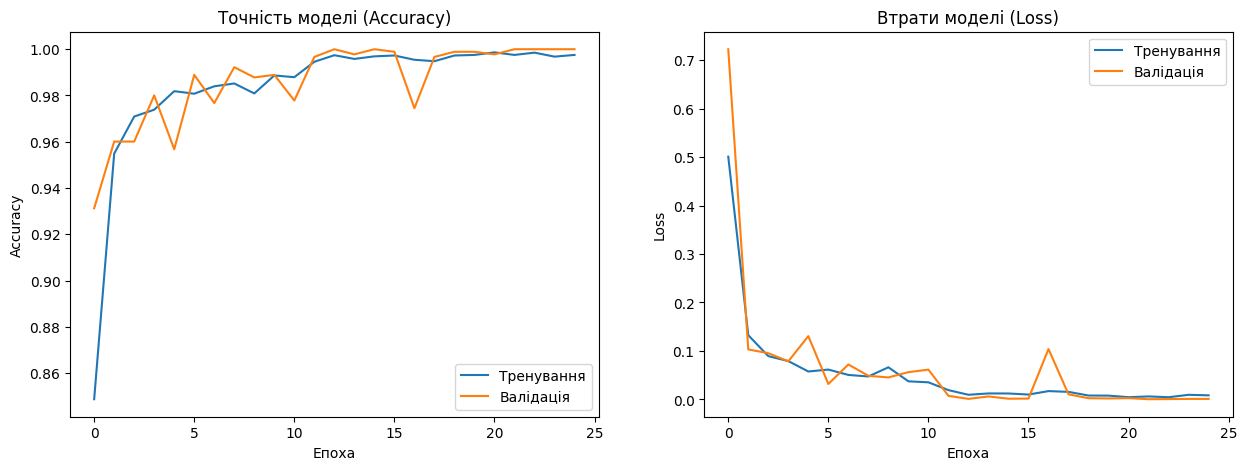

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


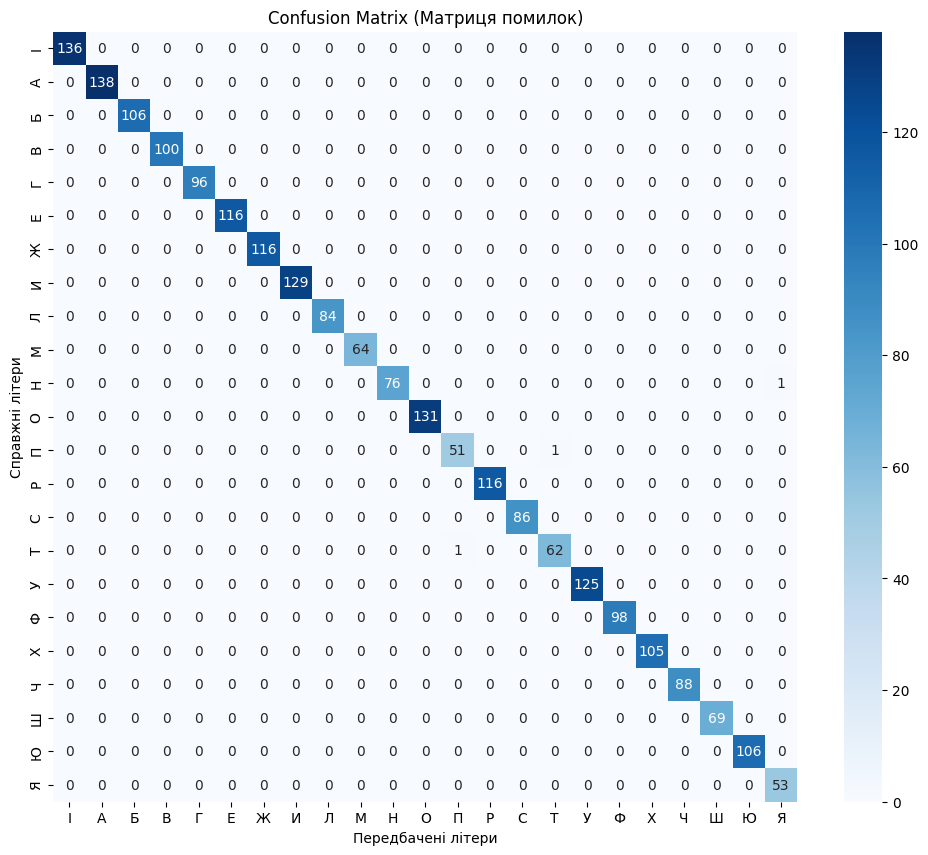


Детальний звіт по метриках:
              precision    recall  f1-score   support

           І       1.00      1.00      1.00       136
           А       1.00      1.00      1.00       138
           Б       1.00      1.00      1.00       106
           В       1.00      1.00      1.00       100
           Г       1.00      1.00      1.00        96
           Е       1.00      1.00      1.00       116
           Ж       1.00      1.00      1.00       116
           И       1.00      1.00      1.00       129
           Л       1.00      1.00      1.00        84
           М       1.00      1.00      1.00        64
           Н       1.00      0.99      0.99        77
           О       1.00      1.00      1.00       131
           П       0.98      0.98      0.98        52
           Р       1.00      1.00      1.00       116
           С       1.00      1.00      1.00        86
           Т       0.98      0.98      0.98        63
           У       1.00      1.00      1.00       12

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf

# Завантаження 
model = tf.keras.models.load_model("sign_language_lstm_model_v11_9759.h5")
data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
with open("training_history_v11.json", "r") as f:
    history_data = json.load(f)

# Оцінка на тестових даних
X_test = data['X_test']
y_test = data['y_test']
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nТочність на тестових даних: {test_acc*100:.2f}%")

# Loss & Accuracy
def plot_history(history_dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history_dict['accuracy'], label='Тренування')
    ax1.plot(history_dict['val_accuracy'], label='Валідація')
    ax1.set_title('Точність моделі (Accuracy)')
    ax1.set_xlabel('Епоха')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax2.plot(history_dict['loss'], label='Тренування')
    ax2.plot(history_dict['val_loss'], label='Валідація')
    ax2.set_title('Втрати моделі (Loss)')
    ax2.set_xlabel('Епоха')
    ax2.set_ylabel('Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_data)

# Конфузійна матриця
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

mapping = data['mapping'].item()
target_names = [l for l, i in sorted(mapping.items(), key=lambda x: x[1])]

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm_normalized, annot=True, fmt='.0%', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.ylabel('Справжні літери')
    plt.xlabel('Передбачені літери')
    plt.show()

plot_confusion_matrix(y_test, y_pred, target_names)

# Precision, Recall, F1-score
print("\nДетальний звіт по метриках:")
print(classification_report(y_test, y_pred, target_names=target_names))

In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def visualize_pca(X, y, mapping):
    if X.ndim > 2:
        X = X.reshape(X.shape[0], -1)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    exp_var = pca.explained_variance_ratio_ * 100
    print(f"Ці два компоненти описують {np.sum(exp_var):.2f}% розкиду даних (PC1: {exp_var[0]:.2f}%, PC2: {exp_var[1]:.2f}%)")
    
    pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
    
    inv_map = {v: k for k, v in mapping.items()} if isinstance(list(mapping.keys())[0], str) else mapping
    
    pca_df['Letter'] = [inv_map.get(int(label), f"ID {label}") for label in y]
    
    plt.figure(figsize=(12, 8))
    sns.scatterplot(
        x='Principal Component 1', 
        y='Principal Component 2', 
        hue='Letter', 
        data=pca_df, 
        palette='tab20',
        alpha=0.7
    )
    
    plt.title('Візуалізація датасету через PCA (2D)')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

data = np.load("ukrainian_sign_dataset/processed/training_data_lstm.npz", allow_pickle=True)
X_train = data['X_train'].reshape(data['X_train'].shape[0], -1)
X_test = data['X_test'].reshape(data['X_test'].shape[0], -1)
X_val = data['X_val'].reshape(data['X_val'].shape[0], -1)
X_full = np.concatenate([X_train, X_val, X_test], axis=0)
y_full = np.concatenate([data['y_train'], data['y_val'], data['y_test']], axis=0)
y_train = data['y_train']
mapping = data['mapping'].item()
visualize_pca(X_full, y_full, mapping)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

data = np.load('ukrainian_sign_dataset/processed/training_data_lstm.npz', allow_pickle=True)

X_full = np.concatenate([data['X_train'], data['X_val'], data['X_test']], axis=0)
y_full = np.concatenate([data['y_train'], data['y_val'], data['y_test']], axis=0)
mapping = data['mapping'].item()

num_samples = min(len(X_full), 15000)
indices = np.random.choice(len(X_full), num_samples, replace=False)

X_subset = X_full[indices]
y_subset = y_full[indices]

X_subset_flat = X_subset.reshape(num_samples, -1)

inv_map = {v: k for k, v in mapping.items()}

print(f"Запуск t-SNE для {num_samples} зразків...")

tsne = TSNE(
    n_components=2, 
    perplexity=30, 
    random_state=42,
    learning_rate='auto',
    init='pca' 
)

X_tsne = tsne.fit_transform(X_subset_flat)

plt.figure(figsize=(14, 10))

labels_ukr = [inv_map.get(int(i), f"ID {i}") for i in y_subset]

df = pd.DataFrame({
    'TSNE1': X_tsne[:, 0],
    'TSNE2': X_tsne[:, 1],
    'Літера': labels_ukr
})

df = df.sort_values('Літера')

scatter = sns.scatterplot(
    x='TSNE1', y='TSNE2',
    hue='Літера',
    palette='tab20', 
    data=df,
    legend='full',
    alpha=0.8,
    edgecolor='w',
    linewidth=0.5
)

plt.title('Візуалізація простору ознак (t-SNE)', fontsize=15)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Літери', ncol=2)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()

plt.show()